# Trabalho 1 – Avaliação do Impacto das Cheias
## Análise Espacial para os Municípios de Coimbra e Figueira da Foz


In [47]:
import os
from osgeo import gdal, ogr
from rasterstats import zonal_stats
import geopandas as gpd
import matplotlib.pyplot as plt

# Diretório de trabalho: pasta Prática/ onde está a pasta Data/
base_dir = "/home/httpirsh/Documentos/Mestrado/Ano 2/Semestre 2/ADE/Prática"
if os.getcwd() != base_dir:
    os.chdir(base_dir)

print("Diretório de trabalho:", os.getcwd())
!mkdir -p Project/python_results


Diretório de trabalho: /home/httpirsh/Documentos/Mestrado/Ano 2/Semestre 2/ADE/Prática


## 1) Preparação dos Dados

Todos os datasets são reprojetados para **EPSG:3763** (Portugal TM06 / ETRS89), o sistema de referência métrico padrão para Portugal, que garante o cálculo correto de áreas e comprimentos. Os passos seguintes são comuns a todas as questões de análise.


### 1.1) Extensão da Cheia – Reprojeção para EPSG:3763

O shapefile da extensão máxima da cheia do Copernicus EMS (EMSR864, MONIT01) está originalmente em **EPSG:4326** (WGS 84 geográfico). É reprojetado para EPSG:3763 para corresponder ao raster do COSc e permitir operações espaciais métricas.


In [48]:
# Reprojetar: EPSG:4326 → EPSG:3763
# -makevalid corrige auto-interseções que podem surgir após reprojeção
!ogr2ogr -overwrite -f "ESRI Shapefile" -s_srs EPSG:4326 -t_srs EPSG:3763 -makevalid \
    Project/python_results/floodArea_3763.shp \
    Data/EMSR864_AOI05_DEL_MONIT01_v1/EMSR864_AOI05_DEL_MONIT01_maximumFloodExtentA_v1.shp


### 1.2) Raster de Uso e Ocupação do Solo – Recorte à Extensão da Cheia

O raster COSc 2025 (já em EPSG:3763, resolução de 10 m) é recortado pela área inundada. Isto reduz o tamanho do ficheiro e restringe os cálculos raster seguintes apenas à área afetada pela cheia.


In [49]:
!gdalwarp -overwrite -dstalpha \
    -cutline Project/python_results/floodArea_3763.shp -crop_to_cutline \
    Data/COSc2025/COSc_2025_N3_v0_TM06.tif \
    Project/python_results/COSc_cropped.tif


Creating output file that is 4437P x 3389L.
Using internal nodata values (e.g. 65535) for image Data/COSc2025/COSc_2025_N3_v0_TM06.tif.
Processing COSc_2025_N3_v0_TM06.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


### 1.3) Limites Administrativos – Extração e Filtragem

As freguesias (`cont_freguesias`) e os municípios (`cont_municipios`) são extraídos do GeoPackage nacional CAOP 2025 e reprojetados para EPSG:3763. As freguesias de **Coimbra** e **Figueira da Foz** são depois filtradas para camadas separadas, utilizadas como zonas de análise.


In [50]:
# Extrair e reprojetar freguesias e municípios da CAOP 2025 para EPSG:3763
!ogr2ogr -overwrite -f "ESRI Shapefile" -t_srs EPSG:3763 \
    Project/python_results Data/Continente_CAOP2025.gpkg cont_freguesias
!ogr2ogr -overwrite -f "ESRI Shapefile" -t_srs EPSG:3763 \
    Project/python_results Data/Continente_CAOP2025.gpkg cont_municipios

# Filtrar as freguesias para os dois municípios em estudo
!ogr2ogr -overwrite -f "ESRI Shapefile" \
    Project/python_results/municipio_Coimbra_withFreguesias.shp \
    Project/python_results/cont_freguesias.shp \
    -where "municipio = 'Coimbra'"
!ogr2ogr -overwrite -f "ESRI Shapefile" \
    Project/python_results/municipio_Figueira_withFreguesias.shp \
    Project/python_results/cont_freguesias.shp \
    -where "municipio = 'Figueira da Foz'"


Warning 6: Normalized/laundered field name: 'distrito_ilha' to 'distrito_i'
Warning 6: Normalized/laundered field name: 'perimetro_km' to 'perimetro_'
Warning 6: Normalized/laundered field name: 'designacao_simplificada' to 'designacao'
Warning 6: Normalized/laundered field name: 'distrito_ilha' to 'distrito_i'
Warning 6: Normalized/laundered field name: 'perimetro_km' to 'perimetro_'
Warning 6: Normalized/laundered field name: 'n_freguesias' to 'n_freguesi'


## 2) Análise Espacial

Em cada questão, a contagem de píxeis do COSc é convertida em área usando **contagem × 100 m²** (píxeis de 10 × 10 m), e depois em hectares (÷ 10 000). Os resultados são calculados **por freguesia** para ambos os municípios.


### a) Área Artificializada Afetada pelas Cheias

As áreas artificializadas correspondem à **classe 100** do COSc (Territórios artificializados), que inclui edifícios, estradas e outras superfícies impermeáveis. Cada píxel = 10 × 10 m = 100 m².

O raster COSc recortado à cheia é reclassificado para manter apenas os píxeis com o código da classe artificializada.


In [51]:
# Extrair píxeis artificializados (classe COSc 100 = Territórios artificializados)
# Cada píxel igual a 100 torna-se 1; todo o resto passa a NoData
!gdal_calc -A Project/python_results/COSc_cropped.tif \
    --outfile=Project/python_results/COSc_cropped_builtup.tif \
    --calc="1*(A==100)" --NoDataValue=0 --overwrite


0...10...20...30...40...50...60...70...80...90...100 - done.


In [52]:
# Estatísticas zonais: contagem de píxeis artificializados por freguesia e município (área = contagem * 100 m²)
for municipio, shp in [
    ("Coimbra",  "Project/python_results/municipio_Coimbra_withFreguesias.shp"),
    ("Figueira", "Project/python_results/municipio_Figueira_withFreguesias.shp")
]:
    source = gpd.read_file(shp)
    stats = zonal_stats(shp, "Project/python_results/COSc_cropped_builtup.tif",
                        stats=["count"], geojson_out=True)
    gdf = gpd.GeoDataFrame.from_features(stats, crs=source.crs)
    gdf["area_m2"] = gdf["count"] * 100
    gdf["area_ha"] = gdf["area_m2"] / 10000
    gdf.to_file(f"Project/python_results/{municipio}_builtup_count.gpkg", driver="GPKG")
    print(f"{municipio} concluído – guardado em Project/python_results/{municipio}_builtup_count.gpkg")


Coimbra concluído – guardado em Project/python_results/Coimbra_builtup_count.gpkg
Figueira concluído – guardado em Project/python_results/Figueira_builtup_count.gpkg


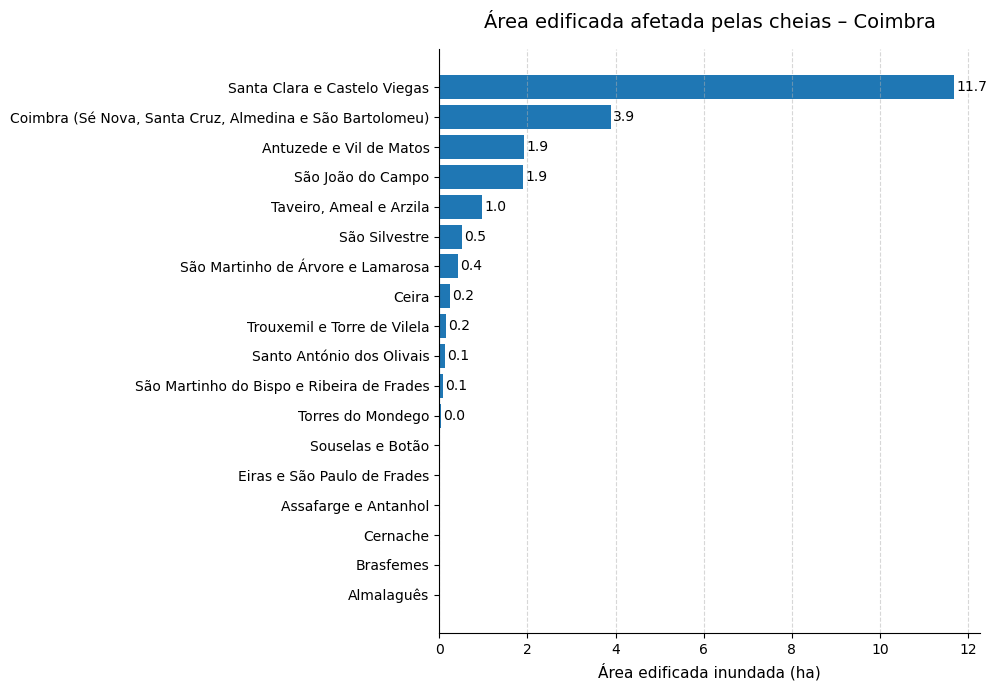

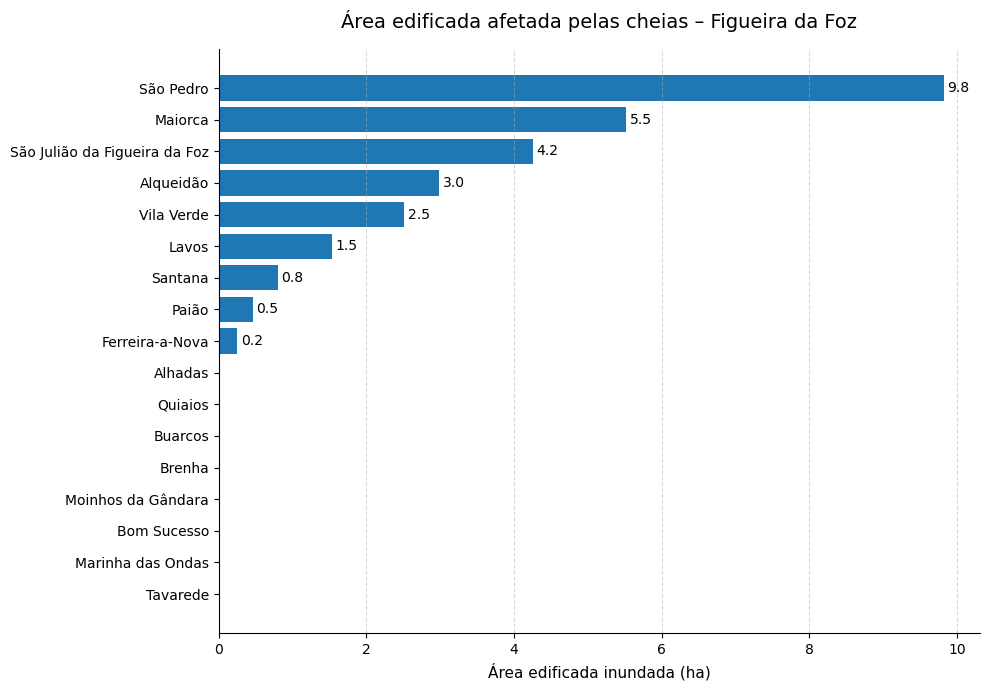

In [53]:
def plot_builtup(gpkg_path, title, output):
    gdf = gpd.read_file(gpkg_path)
    gdf = gdf.sort_values("area_ha", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(gdf["designacao"], gdf["area_ha"])

    for i, v in enumerate(gdf["area_ha"]):
        if v > 0:
            ax.text(v + 0.05, i, f"{v:.1f}", va="center")

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Área edificada inundada (ha)", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(output, dpi=200)
    plt.show()


plot_builtup(
    "Project/python_results/Coimbra_builtup_count.gpkg",
    "Área edificada afetada pelas cheias – Coimbra",
    "Project/python_results/coimbra_builtup_area.png"
)
plot_builtup(
    "Project/python_results/Figueira_builtup_count.gpkg",
    "Área edificada afetada pelas cheias – Figueira da Foz",
    "Project/python_results/figueira_builtup_area.png"
)


### b) Área Agrícola Afetada pelas Cheias

As áreas agrícolas correspondem às seguintes classes do COSc:
- **211** – Culturas anuais de outono/inverno 
- **212** – Culturas anuais de primavera/verão  
- **213** – Outras áreas agrícolas

Cada píxel = 10 × 10 m = 100 m².


In [54]:
# filtrar por classes agrícolas
!gdal_calc -A Project/python_results/COSc_cropped.tif \
    --outfile=Project/python_results/COSc_cropped_agri.tif \
    --calc="1*((A==211)|(A==212)|(A==213))" --NoDataValue=0


0...10...20...30...40...50...60...70...80...90...100 - done.


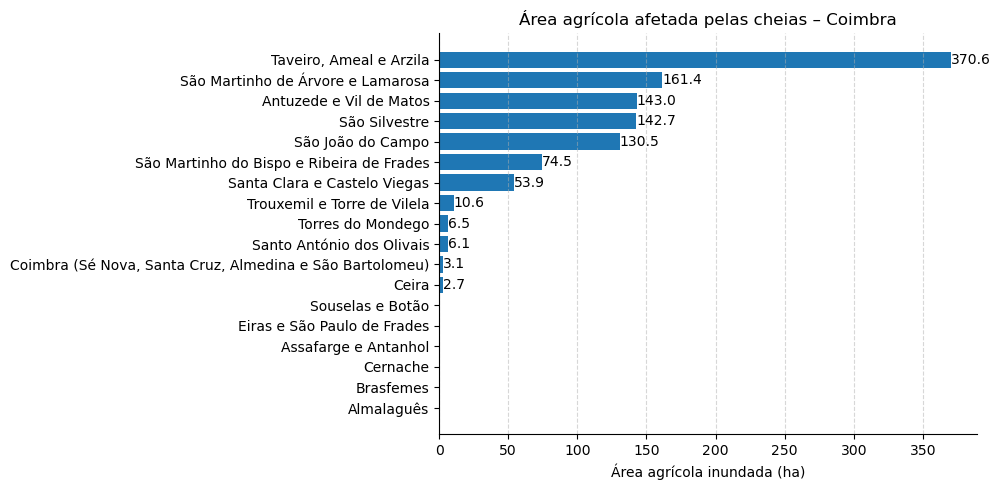

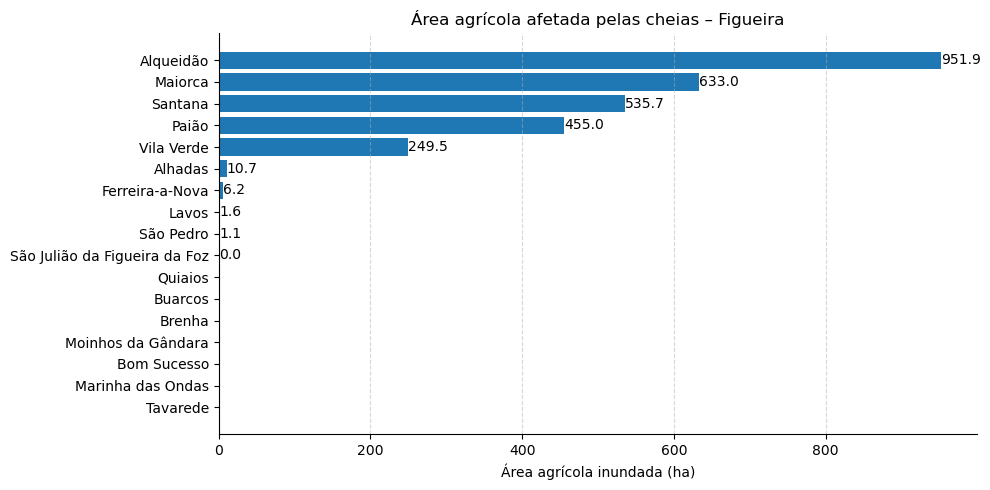

In [55]:
# zonal_stats para as classes agrícolas em ambos os municípios
for municipio, shp in [("Coimbra", "Project/python_results/municipio_Coimbra_withFreguesias.shp"),
                       ("Figueira", "Project/python_results/municipio_Figueira_withFreguesias.shp")]:
    
    source = gpd.read_file(shp)
    stats = zonal_stats(shp, "Project/python_results/COSc_cropped_agri.tif", stats=["count"], geojson_out=True)
    gdf = gpd.GeoDataFrame.from_features(stats, crs=source.crs)
    gdf["area_ha"] = gdf["count"] * 100 / 10000
    gdf.to_file(f"Project/python_results/{municipio}_agri_count.gpkg", driver="GPKG")
    
    # Gráfico de barras (ordenado por área)
    gdf_sorted = gdf.sort_values("area_ha", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(gdf_sorted["designacao"], gdf_sorted["area_ha"])
    for i, v in enumerate(gdf_sorted["area_ha"]):
        if v > 0:
            ax.text(v + 0.01, i, f"{v:.1f}", va="center")
    ax.set_xlabel("Área agrícola inundada (ha)")
    ax.set_title(f"Área agrícola afetada pelas cheias – {municipio}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"Project/python_results/{municipio}_agri_area.png", dpi=150)
    plt.show()


### c) Número de Edifícios Afetados pelas Cheias

As plantas de edifícios do OSM (Geofabrik, originalmente em EPSG:4326) são reprojetadas para EPSG:3763, recortadas à extensão da cheia, convertidas em centroides e contadas por freguesia com um filtro espacial.


In [56]:
# Reprojetar edifícios OSM de EPSG:4326 → EPSG:3763
!ogr2ogr -overwrite -f "ESRI Shapefile" -t_srs EPSG:3763 \
    Project/python_results/buildings_3763.shp \
    Data/portugal-260210-free.shp/gis_osm_buildings_a_free_1.shp

# Recortar à extensão da cheia (ambas as camadas já em EPSG:3763)
!ogr2ogr -overwrite -f "ESRI Shapefile" \
    Project/python_results/buildings_3763_clipped.shp \
    Project/python_results/buildings_3763.shp \
    -clipdst Project/python_results/floodArea_3763.shp


Warning 1: One or several characters couldn't be converted correctly from UTF-8 to ISO-8859-1.  This warning will not be emitted anymore.


In [57]:
# Calcular centroides dos edifícios inundados
gdf_bld = gpd.read_file("Project/python_results/buildings_3763_clipped.shp")
gdf_centroids = gdf_bld.copy()
gdf_centroids.geometry = gdf_centroids.geometry.centroid
gdf_centroids.to_file("Project/python_results/buildings_centroids.shp")
print(f"Total de edifícios inundados: {len(gdf_centroids)}")


Total de edifícios inundados: 600


In [ ]:
def count_buildings_per_freguesia(polygon_path, point_path, output_path):
    polygon_ds = ogr.Open(polygon_path)
    point_ds   = ogr.Open(point_path, 0)

    polygon_layer = polygon_ds.GetLayer()
    point_layer   = point_ds.GetLayer()

    driver = ogr.GetDriverByName("ESRI Shapefile")
    if os.path.exists(output_path):
        driver.DeleteDataSource(output_path)
    out_ds    = driver.CreateDataSource(output_path)
    out_layer = out_ds.CreateLayer("result", srs=polygon_layer.GetSpatialRef())

    layer_defn = polygon_layer.GetLayerDefn()
    for i in range(layer_defn.GetFieldCount()):
        out_layer.CreateField(layer_defn.GetFieldDefn(i))
    out_layer.CreateField(ogr.FieldDefn("bld_count", ogr.OFTInteger))

    for poly_feat in polygon_layer:
        poly_geom = poly_feat.GetGeometryRef()
        point_layer.SetSpatialFilter(poly_geom)
        count = point_layer.GetFeatureCount()
        point_layer.SetSpatialFilter(None)

        out_feat = ogr.Feature(out_layer.GetLayerDefn())
        out_feat.SetGeometry(poly_geom.Clone())
        for i in range(layer_defn.GetFieldCount()):
            out_feat.SetField(i, poly_feat.GetField(i))
        out_feat.SetField("bld_count", count)
        out_layer.CreateFeature(out_feat)
        print(f"  {poly_feat.GetField('designacao')}: {count} edifícios")

    out_ds.FlushCache()
    print(f"Guardado em → {output_path}")


In [59]:
count_buildings_per_freguesia(
    "Project/python_results/municipio_Coimbra_withFreguesias.shp",
    "Project/python_results/buildings_centroids.shp",
    "Project/python_results/Coimbra_buildings_count.shp"
)
count_buildings_per_freguesia(
    "Project/python_results/municipio_Figueira_withFreguesias.shp",
    "Project/python_results/buildings_centroids.shp",
    "Project/python_results/Figueira_buildings_count.shp"
)


  Almalaguês: 0 edifícios
  Brasfemes: 0 edifícios
  Ceira: 0 edifícios
  Cernache: 0 edifícios
  Santo António dos Olivais: 9 edifícios
  São João do Campo: 3 edifícios
  São Silvestre: 0 edifícios
  Torres do Mondego: 0 edifícios
  Antuzede e Vil de Matos: 2 edifícios
  Assafarge e Antanhol: 0 edifícios
  Coimbra (Sé Nova, Santa Cruz, Almedina e São Bartolomeu): 25 edifícios
  Eiras e São Paulo de Frades: 0 edifícios
  Santa Clara e Castelo Viegas: 124 edifícios
  São Martinho de Árvore e Lamarosa: 0 edifícios
  São Martinho do Bispo e Ribeira de Frades: 2 edifícios
  Souselas e Botão: 0 edifícios
  Taveiro, Ameal e Arzila: 10 edifícios
  Trouxemil e Torre de Vilela: 2 edifícios
Guardado em → Project/python_results/Coimbra_buildings_count.shp
  Alqueidão: 17 edifícios
  Maiorca: 5 edifícios
  Marinha das Ondas: 0 edifícios
  Tavarede: 0 edifícios
  Vila Verde: 6 edifícios
  São Pedro: 49 edifícios
  Bom Sucesso: 0 edifícios
  Moinhos da Gândara: 0 edifícios
  Lavos: 101 edifícios
  P

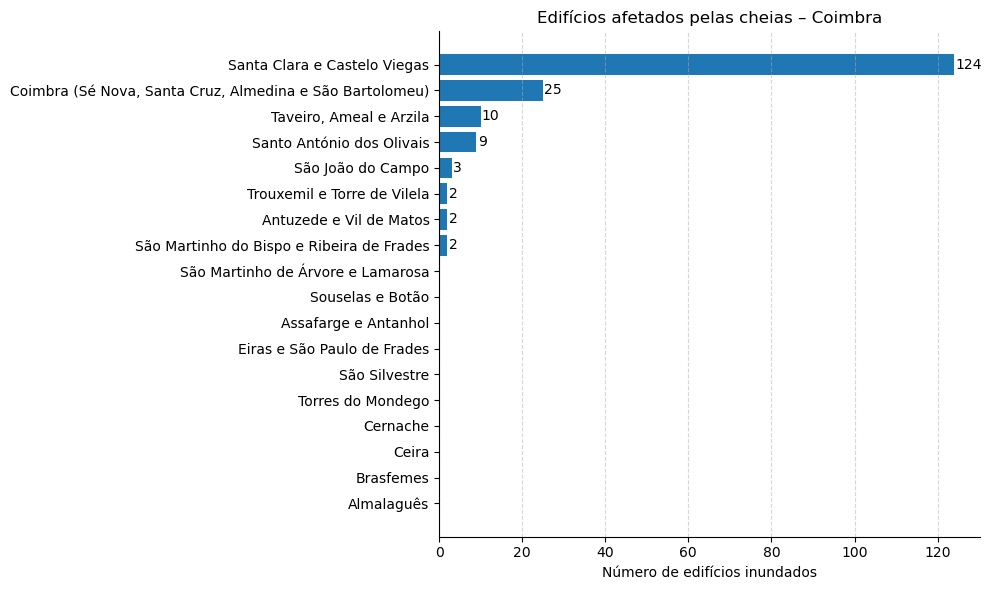

Coimbra: 177 edifícios no total


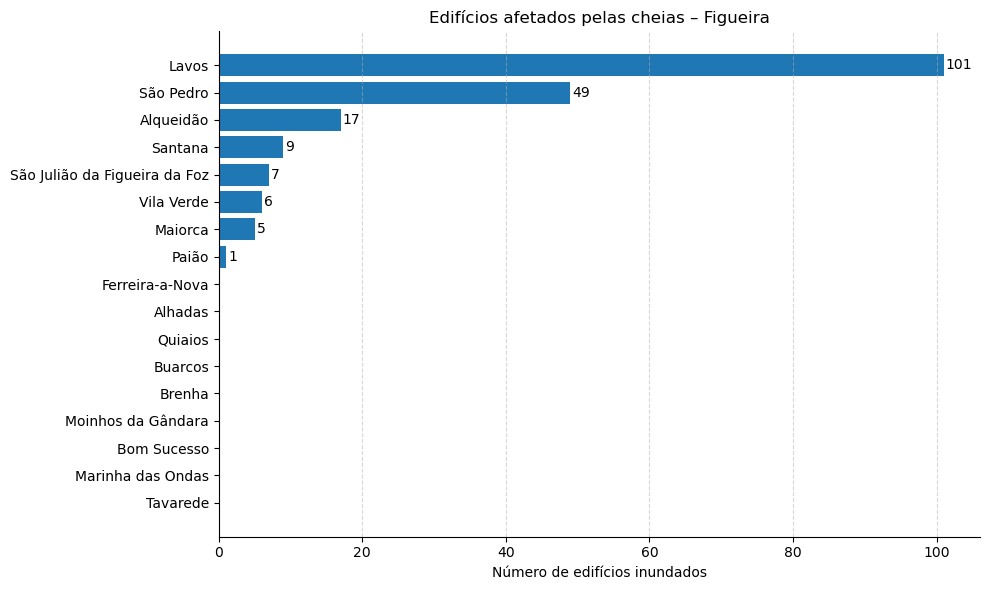

Figueira: 195 edifícios no total


In [60]:

# Gráfico de edifícios afetados por freguesia – Coimbra e Figueira da Foz
for municipio, shp in [
    ("Coimbra",  "Project/python_results/Coimbra_buildings_count.shp"),
    ("Figueira", "Project/python_results/Figueira_buildings_count.shp"),
]:
    gdf = gpd.read_file(shp)
    gdf_sorted = gdf.sort_values("bld_count", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(gdf_sorted["designacao"], gdf_sorted["bld_count"])
    for i, v in enumerate(gdf_sorted["bld_count"]):
        if v > 0:
            ax.text(v + 0.3, i, str(v), va="center")
    ax.set_xlabel("Número de edifícios inundados")
    ax.set_title(f"Edifícios afetados pelas cheias – {municipio}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"Project/python_results/{municipio}_buildings_count.png", dpi=200)
    plt.show()

    print(f"{municipio}: {gdf_sorted['bld_count'].sum()} edifícios no total")


### d) Extensão Areal da Cheia

A área total inundada por freguesia é calculada pela interseção da extensão da cheia com os limites das freguesias.  
Este passo é realizado no **QGIS** (Vetor → Ferramentas de Geoprocessamento → Interseção), seguido do cálculo de campo (`$area / 10000`) e de uma dissolução para agregar por freguesia.

**Metodologia:**
1. Intersetar `floodArea_3763.shp` com os limites das freguesias → polígonos da cheia divididos por freguesia  
2. Calculadora de Campos → `area_ha = $area / 10000`  
3. Dissolver por `designacao`, Soma(area_ha) → área total inundada por freguesia


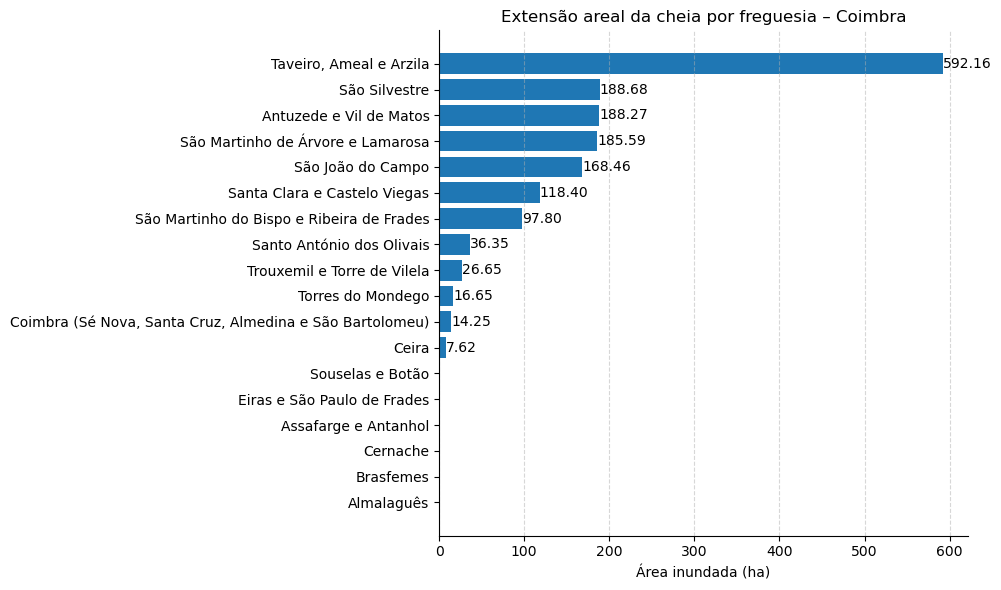

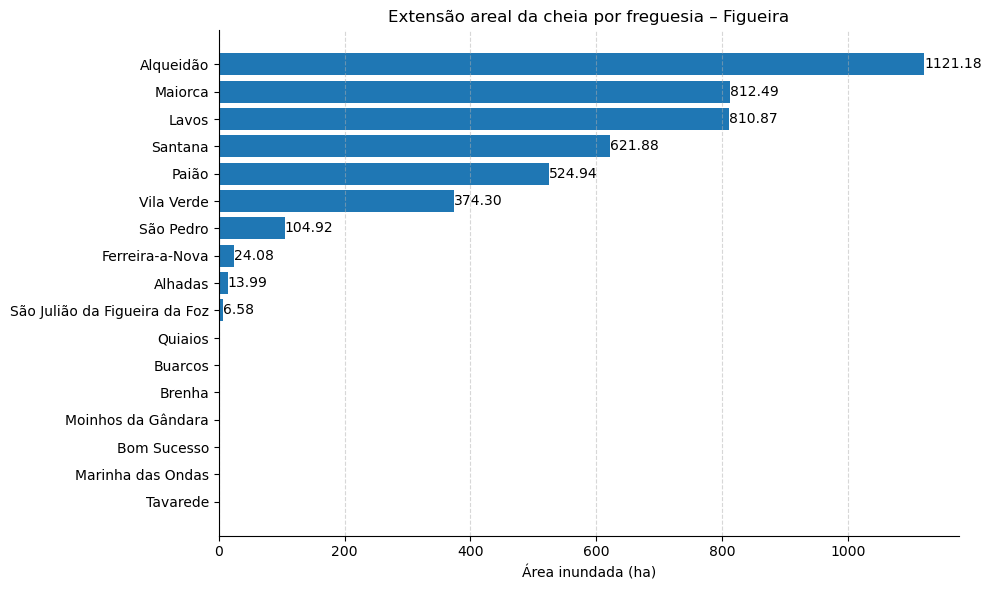

In [61]:
import geopandas as gpd

flood = gpd.read_file("Project/python_results/floodArea_3763.shp")

for municipio, shp in [
    ("Coimbra",  "Project/python_results/municipio_Coimbra_withFreguesias.shp"),
    ("Figueira", "Project/python_results/municipio_Figueira_withFreguesias.shp")
]:
    freguesias = gpd.read_file(shp)
    # remover coluna area_ha existente no shapefile para evitar duplicados
    if "area_ha" in freguesias.columns:
        freguesias = freguesias.drop(columns=["area_ha"])

    # Intersetar a cheia com as freguesias
    intersected = gpd.overlay(flood, freguesias, how="intersection")
    intersected["area_ha"] = intersected.geometry.area / 10000

    # Agregar por designação de freguesia
    resultado = intersected.groupby("designacao", as_index=False)["area_ha"].sum()

    # Juntar de volta com todas as freguesias (left join → 0 nas sem cheia)
    resultado_gdf = freguesias.merge(resultado, on="designacao", how="left")
    resultado_gdf["area_ha"] = resultado_gdf["area_ha"].fillna(0)
    resultado_gdf.to_file(f"Project/python_results/{municipio}_flood_area.gpkg", driver="GPKG")

    # Gráfico com todas as freguesias (ordenadas por área)
    plot_gdf = resultado_gdf[["designacao", "area_ha"]].sort_values("area_ha", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_gdf["designacao"], plot_gdf["area_ha"])
    for i, v in enumerate(plot_gdf["area_ha"]):
        if v > 0:
            ax.text(v + 0.01, i, f"{v:.2f}", va="center")
    ax.set_xlabel("Área inundada (ha)")
    ax.set_title(f"Extensão areal da cheia por freguesia – {municipio}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"Project/python_results/{municipio}_flood_area.png", dpi=200)
    plt.show()


### e) Extensão da Rede Viária Afetada

Feita no QGIS


### f) Extensão da Rede Ferroviária Afetada

Feita no QGIS


### g) População Residente Afetada pelas Cheias

**Pressuposição:** a população é homogeneamente distribuída dentro de cada freguesia. Assim:

$$\text{Pop. afetada} = \frac{\text{Área inundada (ha)}}{\text{Área total da freguesia (ha)}} \times \text{Pop. total da freguesia}$$

Os dados populacionais provêm do **Recenseamento 2021** (INE), ao nível de lugar/localidade. Para **Coimbra**, é utilizado o ficheiro `C21_LUGF0603.gpkg`, com os registos agregados diretamente pelo código de freguesia (campo `FREGUESIA`). Para **Figueira da Foz**, é utilizado o ficheiro `C21_LUGF0605.gpkg`; dado que os códigos de freguesia do INE 2021 não correspondem integralmente aos da CAOP 2025 (devido a uma reorganização administrativa posterior ao censo), recorreu-se a uma **junção espacial** (*spatial join*) entre os lugares (pontos) e os polígonos de freguesia da CAOP 2025.



Coimbra:
  População total: 140,341
  População estimada afetada: 4,939

                                              designacao  pop_total  prop_inundada_%  pop_afetada
                                 Taveiro, Ameal e Arzila       3922            24.33          954
                            Santa Clara e Castelo Viegas      11855             6.72          796
                               Santo António dos Olivais      41149             1.89          776
               São Martinho do Bispo e Ribeira de Frades      15292             3.96          606
                                           São Silvestre       2784            18.37          511
                                       São João do Campo       1820            21.27          387
                                 Antuzede e Vil de Matos       2804            10.68          300
                       São Martinho de Árvore e Lamarosa       2696             8.89          240
Coimbra (Sé Nova, Santa Cruz, Almedina e São

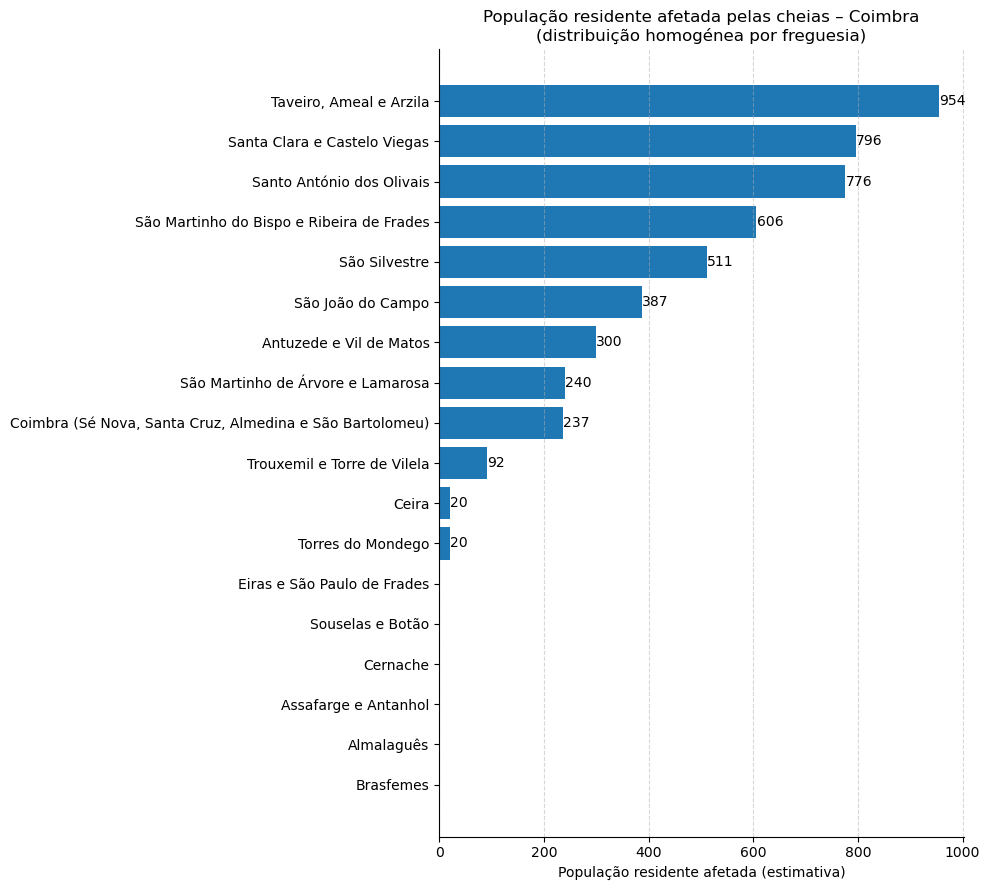


Figueira:
  População total: 58,803
  População estimada afetada: 6,762

                   designacao  pop_total  prop_inundada_%  pop_afetada
                   Vila Verde      13226            21.65         2863
                      Maiorca       2936            32.32          949
                        Paião       5155            16.83          868
                    Alqueidão       1338            57.01          763
                        Lavos       3786            19.30          731
São Julião da Figueira da Foz      11568             1.69          196
                      Santana        458            41.31          189
                    São Pedro       1133            14.98          170
                      Alhadas       4130             0.48           20
              Ferreira-a-Nova        685             1.88           13
                  Bom Sucesso       1479             0.00            0
            Marinha das Ondas       2167             0.00            0
   

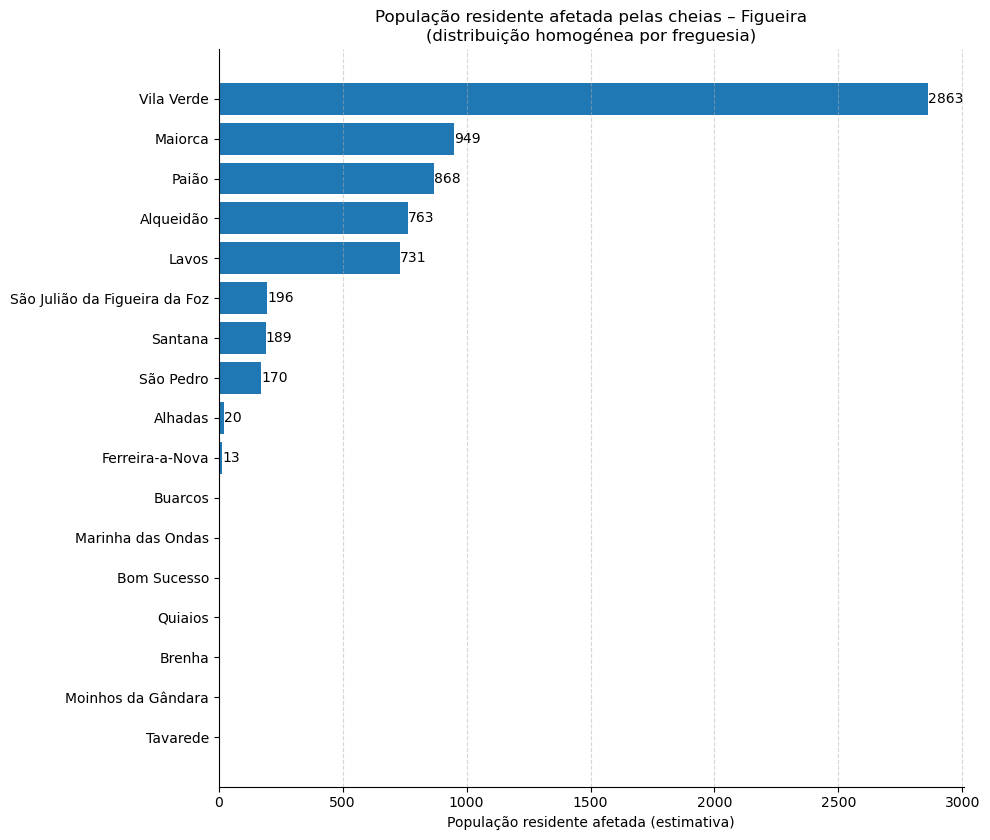

In [62]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# --- 1a. Coimbra: população por lugar (C21_LUGF0603.gpkg, Censos 2021 INE)
# Agrega por código de freguesia (campo FREGUESIA) → população total por freguesia
lugf = gpd.read_file("Project/Data/C21_LUGF0603/C21_LUGF0603.gpkg")
lugf["N_INDIVIDUOS"] = pd.to_numeric(lugf["N_INDIVIDUOS"], errors="coerce").fillna(0)
pop_coimbra = (
    lugf.groupby("FREGUESIA", as_index=False)["N_INDIVIDUOS"]
    .sum()
    .rename(columns={"FREGUESIA": "dtmnfr", "N_INDIVIDUOS": "pop_total"})
)
pop_coimbra["dtmnfr"] = pop_coimbra["dtmnfr"].astype(str).str.zfill(6)
pop_coimbra["pop_total"] = pop_coimbra["pop_total"].round().astype(int)

# --- 1b. Figueira da Foz: população por lugar (C21_LUGF0605.gpkg, Censos 2021 INE)
# Os códigos de freguesia do INE 2021 não correspondem aos da CAOP 2025 para algumas
# freguesias da Figueira da Foz (reorganização administrativa pós-2021).
# Solução: spatial join dos lugares (pontos) com as freguesias da CAOP 2025.
lugf_fig = gpd.read_file("Project/Data/C21_LUGF0605/C21_LUGF0605.gpkg")
lugf_fig["N_INDIVIDUOS"] = pd.to_numeric(lugf_fig["N_INDIVIDUOS"], errors="coerce").fillna(0)
if lugf_fig.crs.to_epsg() != 3763:
    lugf_fig = lugf_fig.to_crs(epsg=3763)

# Carregar freguesias da Figueira (CAOP 2025)
figueira_parishes = gpd.read_file("Project/python_results/municipio_Figueira_withFreguesias.shp")
if figueira_parishes.crs.to_epsg() != 3763:
    figueira_parishes = figueira_parishes.to_crs(epsg=3763)

# Spatial join: cada lugar fica associado à sua freguesia CAOP 2025
# predicate="intersects" garante que pontos em limites de polígonos também são atribuídos
joined_fig = gpd.sjoin(
    lugf_fig[["N_INDIVIDUOS", "geometry"]],
    figueira_parishes[["designacao", "dtmnfr", "geometry"]],
    how="left", predicate="intersects"
)
# Eliminar duplicados (lugares exatamente na fronteira entre duas freguesias)
joined_fig = joined_fig[~joined_fig.index.duplicated(keep="first")]
pop_figueira = (
    joined_fig.groupby("dtmnfr", as_index=False)["N_INDIVIDUOS"]
    .sum()
    .rename(columns={"N_INDIVIDUOS": "pop_total"})
)
pop_figueira["pop_total"] = pop_figueira["pop_total"].round().astype(int)

pop_sources = {"Coimbra": pop_coimbra, "Figueira": pop_figueira}

# --- 2. Processar Coimbra e Figueira da Foz ---
for municipio, shp in [
    ("Coimbra",  "Project/python_results/municipio_Coimbra_withFreguesias.shp"),
    ("Figueira", "Project/python_results/municipio_Figueira_withFreguesias.shp"),
]:
    parishes = gpd.read_file(shp)
    if parishes.crs.to_epsg() != 3763:
        parishes = parishes.to_crs(epsg=3763)
    parishes["area_total_ha"] = parishes.geometry.area / 10000

    # Juntar população pelo código de freguesia
    pop_df = pop_sources[municipio]
    parishes_pop = parishes.merge(pop_df, on="dtmnfr", how="left")
    parishes_pop["pop_total"] = parishes_pop["pop_total"].fillna(0).astype(int)

    # Carregar área inundada por freguesia (resultado da alínea d)
    flood_area = gpd.read_file(f"Project/python_results/{municipio}_flood_area.gpkg")[["designacao", "area_ha"]]

    # Calcular população afetada
    df = parishes_pop[["designacao", "dtmnfr", "area_total_ha", "pop_total"]].merge(
        flood_area, on="designacao", how="left"
    )
    df["area_ha"] = df["area_ha"].fillna(0)
    df["prop_inundada"] = df["area_ha"] / df["area_total_ha"]
    df["pop_afetada"] = (df["prop_inundada"] * df["pop_total"]).round().astype(int)

    # Guardar resultado
    resultado_gdf = parishes.merge(
        df[["designacao", "area_total_ha", "area_ha", "prop_inundada", "pop_total", "pop_afetada"]],
        on="designacao", how="left"
    )
    resultado_gdf.to_file(f"Project/python_results/{municipio}_pop_afetada.gpkg", driver="GPKG")

    # Tabela resumo
    tabela = df[["designacao", "pop_total", "area_ha", "prop_inundada", "pop_afetada"]].copy()
    tabela["prop_inundada_%"] = (tabela["prop_inundada"] * 100).round(2)
    tabela = tabela.sort_values("pop_afetada", ascending=False)
    print(f"\n{municipio}:")
    print(f"  População total: {df['pop_total'].sum():,}")
    print(f"  População estimada afetada: {df['pop_afetada'].sum():,}\n")
    print(tabela[["designacao", "pop_total", "prop_inundada_%", "pop_afetada"]].to_string(index=False))

    # Gráfico
    plot_df = tabela.sort_values("pop_afetada", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.5)))
    ax.barh(plot_df["designacao"], plot_df["pop_afetada"])
    for i, v in enumerate(plot_df["pop_afetada"]):
        if v > 0:
            ax.text(v + 0.5, i, str(v), va="center")
    ax.set_xlabel("População residente afetada (estimativa)")
    ax.set_title(f"População residente afetada pelas cheias – {municipio}\n(distribuição homogénea por freguesia)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"Project/python_results/{municipio}_pop_afetada.png", dpi=200)
    plt.show()
